# IT3381 Assignment - Part 2: AG News Text Classification

## Introduction and Background:
### Problem Statement
News platfoms publish thousand of articles every day across a wide range of topics, and having editors and journalists manually sorting this amount of content into categories is slow, inconsistent and potentially biased, while also being unscalable. Automatic news classification by assigning each article to a category based on its title and description addresses the issue at hand by enabling real time content routing, personalized recommendation, and content moderation at scale.

### Why Deep Learning:
Text classification using classical machine learning (such as in the Text and social analytics project last semester), could in principle work such as using TF-IDF features with an algorithm such as Logistic Regression or Naive Bayes. However, these approaches treat words as independent sparse features, and struggle to capture two things that matter for news text specifically.
- Semantic similarity between words such as recognising that "shares", "stocks" and "markets" all point towards the same topic, even if a specific test article never uses the exact words seen in training.
- Word order and context such as distinguishing something like "Apple reports record iphone sales" and "apple orchard yield record harvest", where the same word carries different meaning based on context.

Deep Learning models address this through word embeddings, which map words into a continuous vector space, where words that have similar meanings, will lie close together in the vector space, and through architectures such as RNNs and transformers that will then model the sequence and context surrounding each word rather than treating text like an unordered bag of tokens.

### Project Objective and approach:
Two deep learning models will be built and compared to represent two different points on the embedding spectrum.

1. Model A is a bidirectional LSTM that uses GloVe embeddings and uses static pretrained word embeddings, where each word has one fixed vector irregardless of context, combined with a bidirectional LSTM to model sequence order on top of these embeddings.
2. Model B is a fine tuned DistilBERT model which uses contextual embeddings from a transformer pretrained on a large text corpus, where the same word can hold different vector representations depending on its context, and this model B will be used as the transfer learning model.

Comparing these two models allow us to evaluate how much benefit contextual, pretrained language understanding provides over a simpler static-embedding architecture for this classification task, in terms of accuracy, per class performance, and also the errors each model makes.

1. Explanatory Data Analysis: understanding class distribution, text length, vocabulary characteristics and lexical overlap between classes.
2. Data Cleaning and Data Preprocessing: clean noisy text, tokenize for model A and B.
3. Modelling: Build, train and tune both models.
4. Model Evaluation: compare performance using quantitaive metrics and evaluations.
5. Discussion and conclusion: Insights on model strengths, weaknesses and trade-offs.


## 1. Setup & Data Loading

The code cells below mount Google Drive to access the AG News CSV files, install and import the required libraries (TensorFlow, Transformers, scikit-learn, plotting tools), and fix a random seed for reproducibility. They then load the train and test CSVs into DataFrames and map the raw numeric labels to readable category names.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/ag_news'
TRAIN_PATH = f'{DATA_DIR}/train.csv'
TEST_PATH  = f'{DATA_DIR}/test.csv'

Mounted at /content/drive


In [2]:
!pip install -q transformers datasets wordcloud umap-learn matplotlib-venn

import numpy as np
import pandas as pd
import re
import string
import time
import random

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('TF version:', tf.__version__)
print('GPU available (TF):', tf.config.list_physical_devices('GPU'))
print('PyTorch device:', device)

TF version: 2.20.0
GPU available (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch device: cuda


In [3]:
col_names = ['label', 'title', 'description']

def load_ag_news(csv_path):
    df = pd.read_csv(csv_path, header=None, names=col_names)
    if not str(df.iloc[0]['label']).strip().isdigit():
        print(f'Header row detected and dropped: {tuple(df.iloc[0])}')
        df = df.iloc[1:].reset_index(drop=True)
    return df

train_df = load_ag_news(TRAIN_PATH)
test_df  = load_ag_news(TEST_PATH)

label_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
CLASS_NAMES = list(label_map.values())

train_df['label'] = train_df['label'].astype(int) - 1
test_df['label']  = test_df['label'].astype(int) - 1
train_df['label_name'] = train_df['label'].map(lambda x: label_map[x+1])
test_df['label_name']  = test_df['label'].map(lambda x: label_map[x+1])

print(train_df.shape, test_df.shape)
train_df.head()


Header row detected and dropped: ('Class Index', 'Title', 'Description')
Header row detected and dropped: ('Class Index', 'Title', 'Description')
(120000, 4) (7600, 4)


,label,title,description,label_name
0,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business
4,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business


## 2. Exploratory Data Analysis (EDA)

Before building any model, this section explores the dataset to understand its structure and quality. This includes checking class balance with a bar chart, examining text length with a histogram and boxplot, analyzing vocabulary size and rarity with a word frequency (Zipf) plot, and comparing class-level language using word clouds, bigram frequency charts, and a TF-IDF similarity heatmap, alongside checks for missing values, duplicates, and noisy text. The findings from this section directly inform later decisions such as sequence length, vocabulary size, and text cleaning steps.

### 2.1 Class balance bar chart
This bar chart plots the number of training samples in each of the four categories, and serves as evidence to if the dataset is balanced or skewed toward certain classes.
The code below uses `seaborn.countplot` to draw the bar chart and then prints the exact per-class counts with `value_counts()` for a numeric check alongside the visual one.

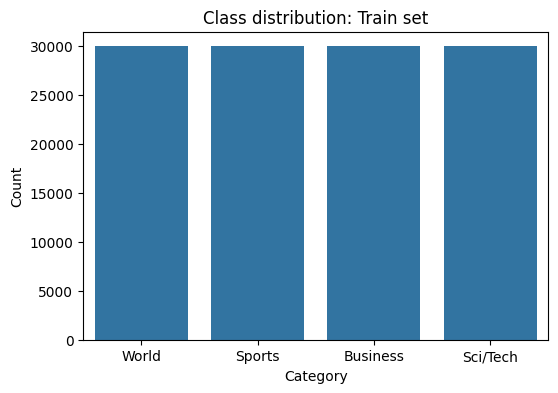

label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [4]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=train_df, x='label_name', order=CLASS_NAMES, ax=ax)
ax.set_title('Class distribution: Train set')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.show()

print(train_df['label_name'].value_counts())


### 2.2 Missing values & duplicates check
Checks the dataset for missing fields and duplicate rows, which could distort training or let identical samples leak across train, validation and test split.
The code counts nulls per column with `isnull().sum()` and checks for exact duplicate rows as well as rows that share the same title and description, since either issue could bias the training data.

In [5]:
print('Missing values:\n', train_df.isnull().sum())
print('\nExact duplicate rows:', train_df.duplicated().sum())
print('Duplicate (title+description) rows:',
      train_df.duplicated(subset=['title', 'description']).sum())


Missing values:
 label          0
title          0
description    0
label_name     0
dtype: int64

Exact duplicate rows: 0
Duplicate (title+description) rows: 0


### 2.3 Raw text quality inspection
Sample rows are likely to contain web scraping artifacts such as (%lt;, &amp;) or stray backslashes, and this step is used to justify the need for the removal of such html tags.
 The code filters rows whose description matches an HTML-entity or backslash pattern using a regex, prints how many rows are affected, and displays a handful of examples so the noise can be inspected directly.

In [6]:
sample_noisy = train_df[train_df['description'].str.contains(
    r'&\w+;|\\', regex=True, na=False)]
print(f'{len(sample_noisy)} rows contain HTML-entity-like patterns')
sample_noisy[['title','description']].head(5)


14535 rows contain HTML-entity-like patterns


,title,description
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
5,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...


### 2.4 Combined text length histogram + boxplot
This histogram shows the distribution of word counts across all combined samples (title + description), with a line marking the 95th percentile, while the boxplot breaks down the same length distibution down by category instead. They reveal how long articles typically are and whether or not a certain category tends to produce longer texts or articles.

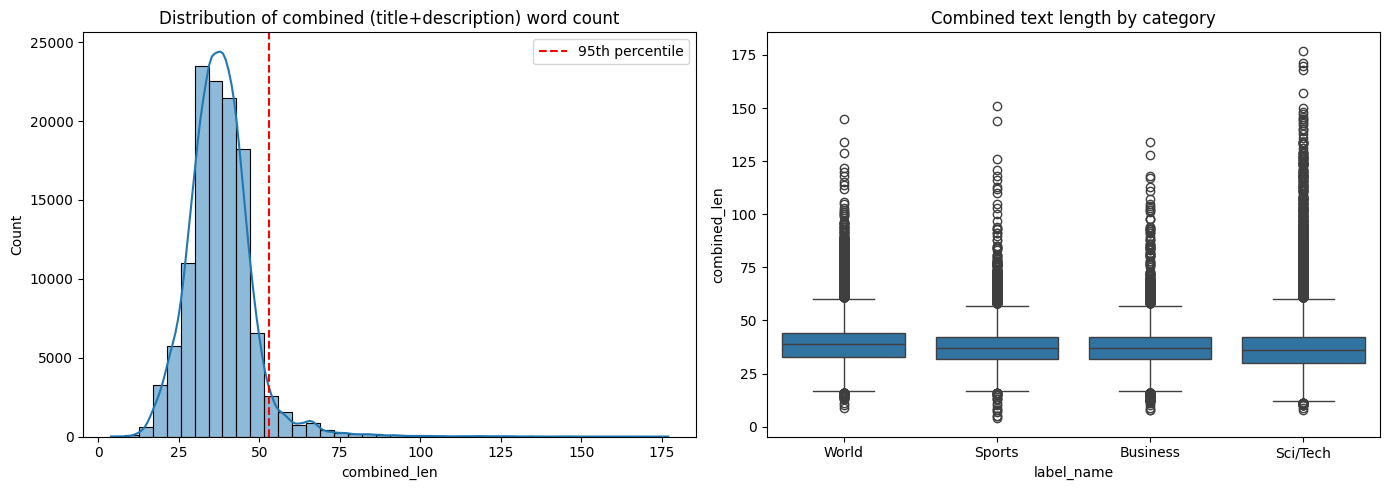

95th percentile word count: 53


In [7]:
_title = train_df['title'].fillna('')
_desc  = train_df['description'].fillna('')

train_df['combined_text'] = _title + ' ' + _desc
train_df['title_len'] = _title.str.split().apply(len)
train_df['desc_len']  = _desc.str.split().apply(len)
train_df['combined_len'] = train_df['combined_text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(train_df['combined_len'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Distribution of combined (title+description) word count')
axes[0].axvline(train_df['combined_len'].quantile(0.95), color='red', linestyle='--',
                 label='95th percentile')
axes[0].legend()

sns.boxplot(data=train_df, x='label_name', y='combined_len', order=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Combined text length by category')
plt.tight_layout()
plt.show()

p95 = int(train_df['combined_len'].quantile(0.95))
print(f'95th percentile word count: {p95}')


### 2.5 Word frequency rank plot
This plot shows the word frequency against frequency rank across the entire vocabulary, which could show that a small number of words account for a disproportionate share of the total word occurences. This will be used later to determine how big the vocabulary size should be for the tokenizer.
The code also computes the cumulative frequency across ranked words to find how many of the most common words are needed to cover 95% of all token occurrences, which sets the tokenizer vocabulary size later.

Vocabulary size (unique tokens): 65008


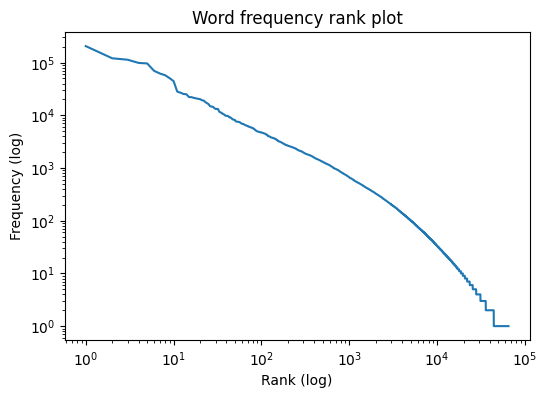

Number of top words covering 95% of token occurrences: 11873


In [8]:
def simple_tokenize(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    return text.split()

all_tokens = train_df['combined_text'].apply(simple_tokenize)
word_counts = Counter([w for toks in all_tokens for w in toks])
print('Vocabulary size (unique tokens):', len(word_counts))

freqs = sorted(word_counts.values(), reverse=True)
plt.figure(figsize=(6,4))
plt.loglog(range(1, len(freqs)+1), freqs)
plt.title('Word frequency rank plot')
plt.xlabel('Rank (log)')
plt.ylabel('Frequency (log)')
plt.show()

cum_freq = np.cumsum(freqs) / sum(freqs)
vocab_95 = np.searchsorted(cum_freq, 0.95) + 1
print(f'Number of top words covering 95% of token occurrences: {vocab_95}')

### 2.6 Word clouds per class.
One word cloud is generated per class, totalling four, from the most frequent non stopword terms in each class's text. If the word clouds show unique vocabularies for each class, this shows that the embedding-based model should be able to learn meaningful, separable representations for classification.

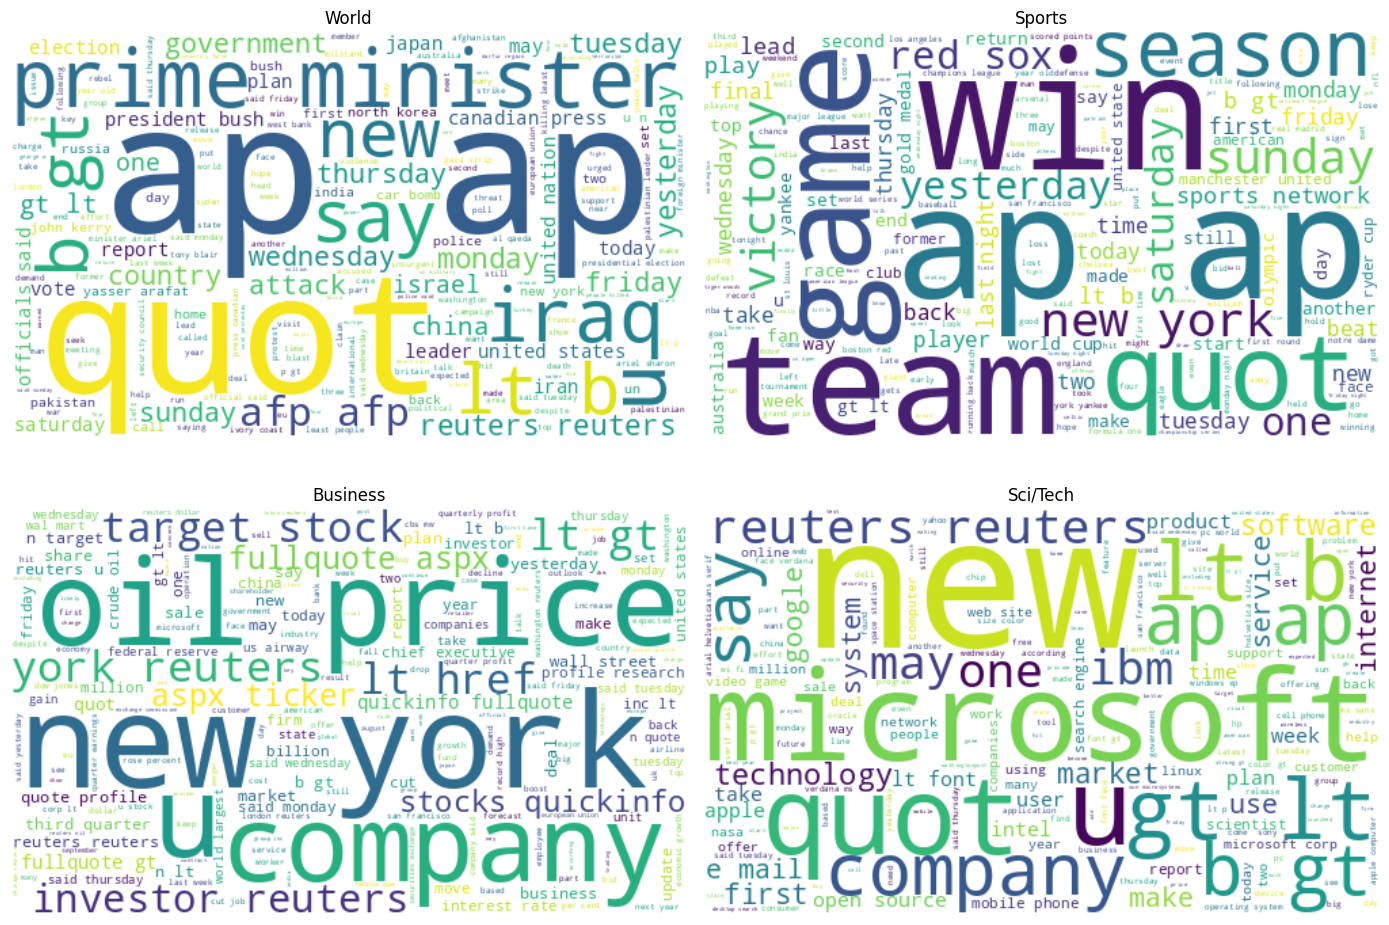

In [9]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, name in zip(axes.flatten(), CLASS_NAMES):
    text = ' '.join(train_df[train_df['label_name'] == name]['combined_text'])
    text = ' '.join([w for w in simple_tokenize(text) if w not in stop_words])
    wc = WordCloud(width=500, height=300, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 2.7 Top bigram bar charts per class
The bar charts show the most frequent two word phrases (bigrams), within each category's text, rather than words in isolation. Some topics can be better identified by bigrams than just single words, such as `stock market` or `world cup` carry more meaning together than apart, this also reveals the signal that single word frequency visualisations might miss.

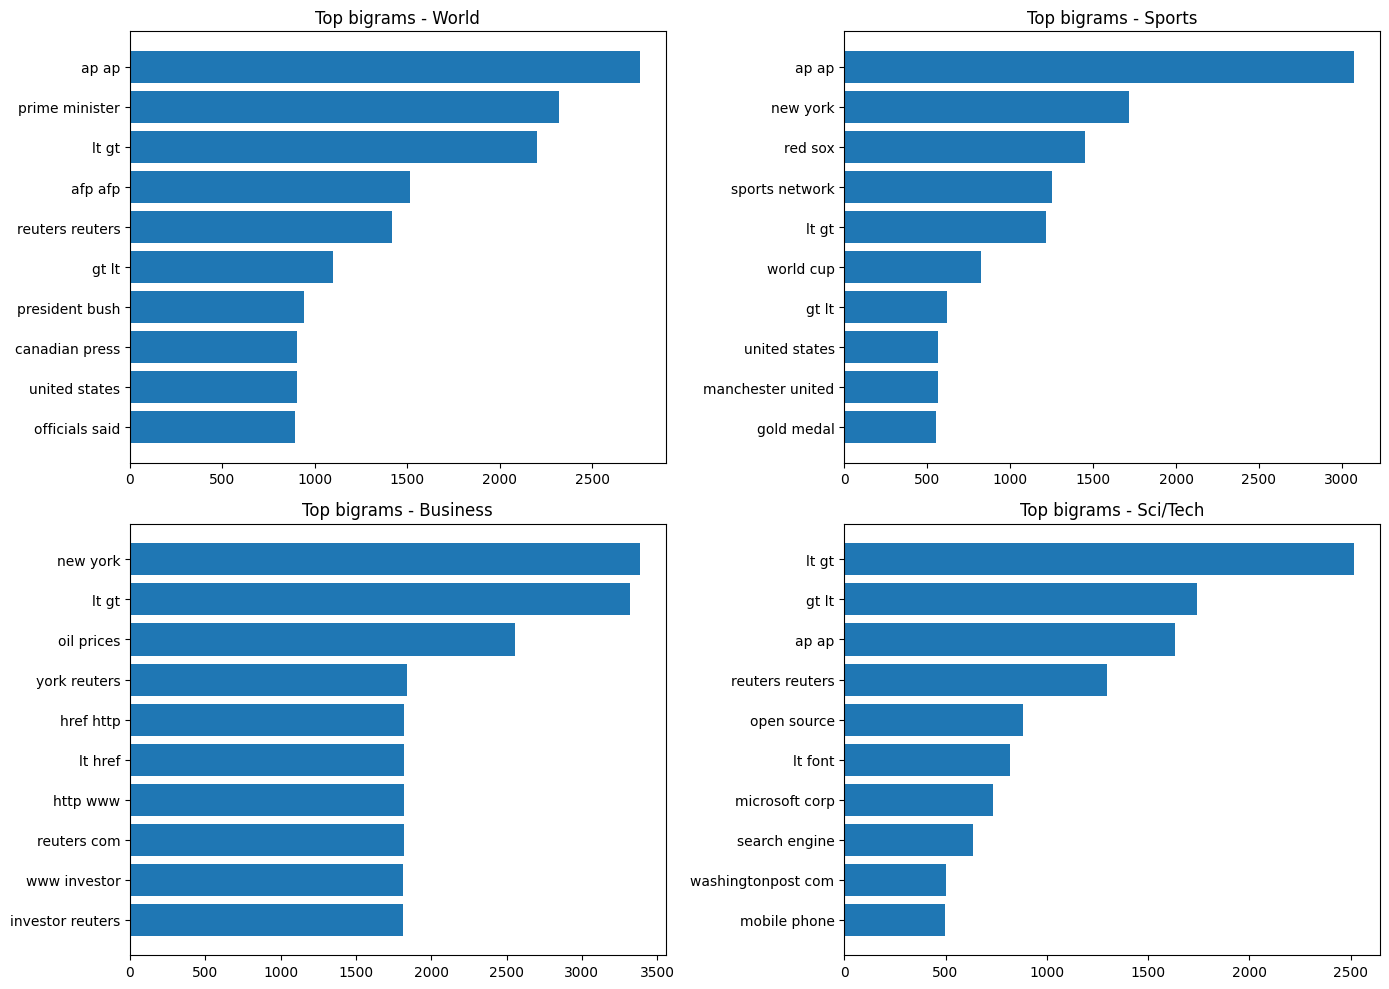

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n,n), stop_words='english', max_features=5000)
    X = vec.fit_transform(corpus)
    sums = X.sum(axis=0)
    freq = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(freq, key=lambda x: -x[1])[:top_k]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, name in zip(axes.flatten(), CLASS_NAMES):
    corpus = train_df[train_df['label_name'] == name]['combined_text']
    bigrams = top_ngrams(corpus, n=2, top_k=10)
    words, counts = zip(*bigrams)
    ax.barh(words, counts)
    ax.set_title(f'Top bigrams - {name}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 2.8 TF-IDF class similarity heatmap
This heatmap shows how similar each pair of classes is in the vocabulary, using TF-IDF cosine similarity. Higher scores predict which classes are more likely to be confused by the models later.

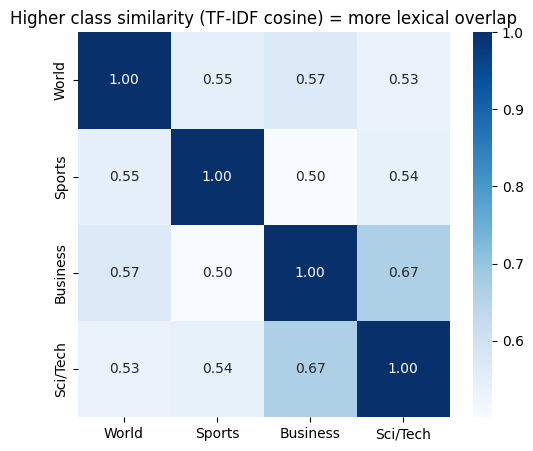

In [11]:
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
class_docs = [' '.join(train_df[train_df['label_name']==name]['combined_text'])
              for name in CLASS_NAMES]
tfidf_matrix = tfidf.fit_transform(class_docs)

from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(sim_matrix, annot=True, fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.title('Higher class similarity (TF-IDF cosine) = more lexical overlap')
plt.show()


## 3. Data Cleaning & Data Preprocessing

This section applies the cleaning and preprocessing decisions justified in the EDA section above. This includes dropping the null and duplicate rows found in section 2.2 (before splitting, so identical articles cannot straddle the train and validation sets), fixing the HTML entity noise found in section 2.3, then creating a stratified train/validation split. Preprocessing then branches by model: Model A gets lowercased, punctuation-stripped, tokenized. Model B uses the DistilBERT tokenizer on minimally cleaned text, since transformer tokenizer handles the casing and punctuation natively.

In [12]:
rows_before = len(train_df)
train_df = train_df.dropna(subset=['title', 'description'])
train_df = train_df.drop_duplicates(subset=['title', 'description']).reset_index(drop=True)
print(f'Dropped {rows_before - len(train_df)} null/duplicate training rows '
      f'({rows_before} -> {len(train_df)})')

def clean_text(text):
    # cleaning of html tags
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&#39;', "'", text)
    text = re.sub(r'\\', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['combined_text'].apply(clean_text)

test_null_rows = test_df['title'].isnull().sum() + test_df['description'].isnull().sum()
if test_null_rows:
    print(f'Filled {test_null_rows} null title/description value(s) in the test set with '
          f'an empty string (test rows are never dropped)')
test_df['combined_text'] = test_df['title'].fillna('') + ' ' + test_df['description'].fillna('')
test_df['clean_text'] = test_df['combined_text'].apply(clean_text)

# For model A only, additionally lowercase + strip punctuation
def clean_text_for_embedding(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text_for_a'] = train_df['clean_text'].apply(clean_text_for_embedding)
test_df['text_for_a']  = test_df['clean_text'].apply(clean_text_for_embedding)

"""for the transformer model, keep clean text as is since tokenizer
handles casing/punctuation and over cleaning might hurt subword tokenization"""

train_df[['clean_text', 'text_for_a']].head()


Dropped 0 null/duplicate training rows (120000 -> 120000)


,clean_text,text_for_a
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...


In [13]:
y_train_full = train_df['label']

train_idx, val_idx = train_test_split(
    train_df.index, test_size=0.1, stratify=y_train_full, random_state=SEED)

train_split = train_df.loc[train_idx].reset_index(drop=True)
val_split   = train_df.loc[val_idx].reset_index(drop=True)

print('Train:', train_split.shape, 'Val:', val_split.shape, 'Test:', test_df.shape)
print(train_split['label_name'].value_counts(normalize=True))
print(val_split['label_name'].value_counts(normalize=True))


Train: (108000, 10) Val: (12000, 10) Test: (7600, 7)
label_name
Sports      0.25
Business    0.25
Sci/Tech    0.25
World       0.25
Name: proportion, dtype: float64
label_name
Sci/Tech    0.25
World       0.25
Business    0.25
Sports      0.25
Name: proportion, dtype: float64


### 3.1 Pre-processing for Model A (Tokenizer + padding + GloVe embedding matrix)

The code below fits a Keras `Tokenizer` on the cleaned Model A text, converts each split into padded integer sequences using the 95th-percentile length and vocabulary size found during EDA, then downloads GloVe vectors and builds an embedding matrix mapping each vocabulary token to its pretrained vector.

In [14]:
MAX_LEN = p95
VOCAB_SIZE = vocab_95
EMBED_DIM = 100

tokenizer_a = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')
tokenizer_a.fit_on_texts(train_split['text_for_a'])

def to_padded_seq(texts):
    seqs = tokenizer_a.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_a = to_padded_seq(train_split['text_for_a'])
X_val_a   = to_padded_seq(val_split['text_for_a'])
X_test_a  = to_padded_seq(test_df['text_for_a'])

y_train_a = train_split['label'].values
y_val_a   = val_split['label'].values
y_test_a  = test_df['label'].values

print(X_train_a.shape, X_val_a.shape, X_test_a.shape)

(108000, 53) (12000, 53) (7600, 53)


In [15]:
!wget -q -nc https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q -n glove.6B.zip glove.6B.100d.txt

embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vec

word_index = tokenizer_a.word_index
num_words = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBED_DIM))

real_vocab = 0
found = 0
for word, i in word_index.items():
    if i >= num_words or i <= 1:
        continue
    real_vocab += 1
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        found += 1

print(f'GloVe coverage: {found}/{real_vocab} ({found/real_vocab:.1%}) vocabulary words found')
print(f'Out-of-vocabulary (no GloVe vector): {real_vocab - found} ({1 - found/real_vocab:.1%})')


GloVe coverage: 11805/11871 (99.4%) vocabulary words found
Out-of-vocabulary (no GloVe vector): 66 (0.6%)


### 3.2 Pre-processing for Model B (DistilBERT tokenizer)

The code below loads the pretrained DistilBERT tokenizer and uses it to encode the train, validation, and test text into PyTorch input ID and attention mask tensors, applying padding and truncation to a fixed maximum length. It also defines a small `Dataset` wrapper class that pairs each encoding with its label so PyTorch's `DataLoader` can batch them during training and inference.

In [16]:
BERT_MODEL_NAME = 'distilbert-base-uncased'
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL_NAME)

BERT_MAX_LEN = 64

def bert_encode(texts, max_len=BERT_MAX_LEN):
    return bert_tokenizer(
        list(texts), max_length=max_len, truncation=True,
        padding='max_length', return_tensors='pt')

train_enc = bert_encode(train_split['clean_text'])
val_enc   = bert_encode(val_split['clean_text'])
test_enc  = bert_encode(test_df['clean_text'])

y_train_b = train_split['label'].values
y_val_b   = val_split['label'].values
y_test_b  = test_df['label'].values

class BertDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## 4. Model A: Embedding (GloVe) + BiLSTM

Static/non-contextual embeddings: each word maps to one fixed vector regardless
of context. The BiLSTM layer models word order/sequence on top of these
embeddings.

The code below defines and compiles this architecture, freezing the GloVe embedding layer and feeding its output through the BiLSTM, dropout, and dense layers to produce a 4-class softmax prediction, then trains it with early stopping on validation loss.


In [17]:
from tensorflow.keras.initializers import Constant

def build_model_a(num_words, embed_dim, embedding_matrix, max_len, num_classes=4):
    inp = Input(shape=(max_len,))

    x = Embedding(input_dim=num_words, output_dim=embed_dim,
                   embeddings_initializer=Constant(embedding_matrix),
                   trainable=False)(inp)
    x = Bidirectional(LSTM(64, return_sequences=False))(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model

model_a = build_model_a(num_words, EMBED_DIM, embedding_matrix, MAX_LEN)
model_a.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 53)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 53, 100)        │     1,187,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,296 (4.88 MB)

 Trainable params: 92,996 (363.27 KB)

 Non-trainable params: 1,187,300 (4.53 MB)

In [18]:
early_stop_a = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

start = time.time()
history_a = model_a.fit(
    X_train_a, y_train_a,
    validation_data=(X_val_a, y_val_a),
    epochs=10, batch_size=64,
    callbacks=[early_stop_a])
train_time_a = time.time() - start
print(f'Model A training time: {train_time_a:.1f}s')

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8811 - loss: 0.3529 - val_accuracy: 0.9062 - val_loss: 0.2677
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9066 - loss: 0.2718 - val_accuracy: 0.9137 - val_loss: 0.2437
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9152 - loss: 0.2451 - val_accuracy: 0.9166 - val_loss: 0.2346
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9219 - loss: 0.2260 - val_accuracy: 0.9218 - val_loss: 0.2255
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9269 - loss: 0.2103 - val_accuracy: 0.9221 - val_loss: 0.2191
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9326 - loss: 0.1966 - val_accuracy: 0.9246 - val_loss: 0.2202
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9365 - loss: 0.1836 - val_accuracy: 0.9214 - val_loss: 0.2256
Model A training time: 113.4s


## 5. Model B: Fine-tuned DistilBERT

Contextual embeddings: the same word gets a different representation depending
on surrounding context, via a transformer pretrained on a large corpus (transfer
learning).

The code below loads a pretrained DistilBERT model with a classification head attached and moves it to GPU if available, sets up an AdamW optimizer with a low learning rate suited to fine-tuning, then trains it with a manual PyTorch loop across batches, applying early stopping on validation loss.

In [19]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=4).to(device)

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)
print(f'Total parameters: {sum(p.numel() for p in bert_model.parameters()):,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,956,548


In [20]:
train_dataset_b = BertDataset(train_enc, y_train_b)
val_dataset_b   = BertDataset(val_enc, y_val_b)

train_loader = DataLoader(train_dataset_b, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset_b, batch_size=32)

class History:
    def __init__(self):
        self.history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.set_grad_enabled(is_train):
            outputs = model(input_ids=batch['input_ids'],
                             attention_mask=batch['attention_mask'],
                             labels=batch['labels'])
            loss = outputs.loss
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * batch['labels'].size(0)
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].size(0)
    return total_loss / total, correct / total

history_b = History()
patience, best_val_loss, epochs_no_improve, best_state = 1, float('inf'), 0, None

start = time.time()
for epoch in range(3):
    train_loss, train_acc = run_epoch(bert_model, train_loader, optimizer)
    val_loss, val_acc = run_epoch(bert_model, val_loader)
    history_b.history['loss'].append(train_loss)
    history_b.history['accuracy'].append(train_acc)
    history_b.history['val_loss'].append(val_loss)
    history_b.history['val_accuracy'].append(val_acc)
    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in bert_model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print('Early stopping triggered')
            break

if best_state is not None:
    bert_model.load_state_dict(best_state)

train_time_b = time.time() - start
print(f'Model B training time: {train_time_b:.1f}s')

Epoch 1: train_loss=0.2335 train_acc=0.9218 val_loss=0.1737 val_acc=0.9388
Epoch 2: train_loss=0.1405 train_acc=0.9525 val_loss=0.1687 val_acc=0.9429
Epoch 3: train_loss=0.0960 train_acc=0.9666 val_loss=0.1755 val_acc=0.9453
Early stopping triggered
Model B training time: 930.9s


## 6. Model Evaluation & Comparison

### 6.1 Training curves

The code below plots the training and validation accuracy and loss curves for both models side by side across epochs, making it easy to compare convergence speed and spot overfitting.

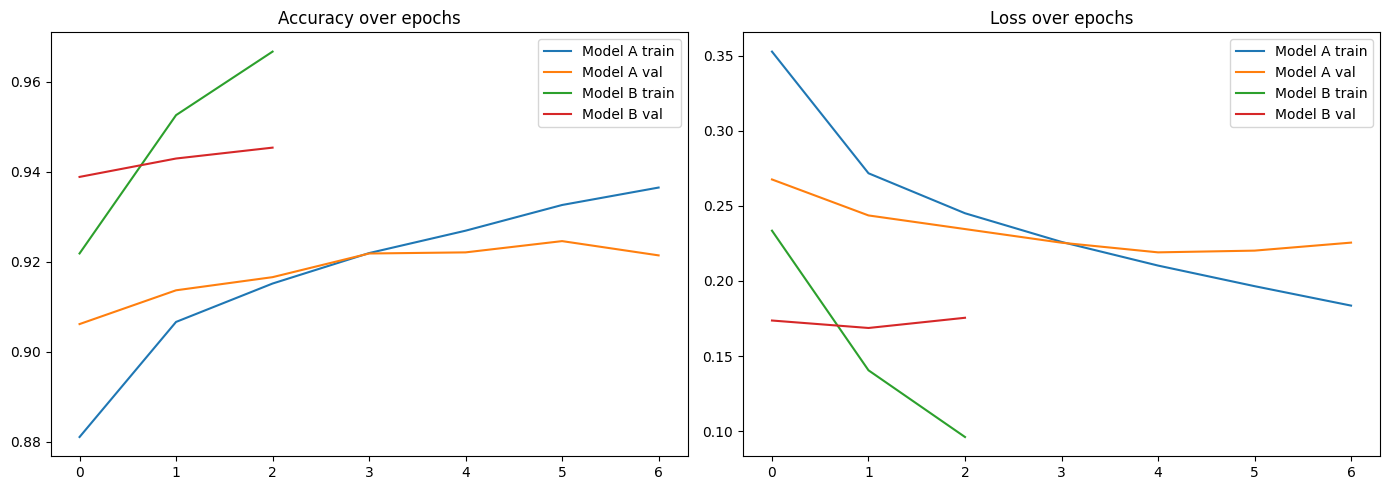

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_a.history['accuracy'], label='Model A train')
axes[0].plot(history_a.history['val_accuracy'], label='Model A val')
axes[0].plot(history_b.history['accuracy'], label='Model B train')
axes[0].plot(history_b.history['val_accuracy'], label='Model B val')
axes[0].set_title('Accuracy over epochs')
axes[0].legend()

axes[1].plot(history_a.history['loss'], label='Model A train')
axes[1].plot(history_a.history['val_loss'], label='Model A val')
axes[1].plot(history_b.history['loss'], label='Model B train')
axes[1].plot(history_b.history['val_loss'], label='Model B val')
axes[1].set_title('Loss over epochs')
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.2 Predictions on test set

The code below generates predictions on the held-out test set for both models, converting Model A's softmax output and Model B's logits into predicted class labels, then prints a full classification report (precision, recall, F1) for each model.

In [22]:
pred_probs_a = model_a.predict(X_test_a)
pred_a = np.argmax(pred_probs_a, axis=1)

test_dataset_b = BertDataset(test_enc, y_test_b)
test_loader = DataLoader(test_dataset_b, batch_size=32)

bert_model.eval()
all_logits = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        all_logits.append(outputs.logits.cpu())
logits_b = torch.cat(all_logits)
pred_probs_b = torch.softmax(logits_b, dim=1).numpy()
pred_b = np.argmax(pred_probs_b, axis=1)

y_true = test_df['label'].values

print('Model A')
print(classification_report(y_true, pred_a, target_names=CLASS_NAMES))
print('Model B')
print(classification_report(y_true, pred_b, target_names=CLASS_NAMES))


238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Model A
              precision    recall  f1-score   support

       World       0.95      0.90      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.88      0.88      1900
    Sci/Tech       0.88      0.91      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

Model B
              precision    recall  f1-score   support

       World       0.94      0.95      0.95      1900
      Sports       0.98      0.99      0.99      1900
    Business       0.93      0.90      0.92      1900
    Sci/Tech       0.91      0.93      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



### 6.3 Confusion matrices side by side

The code below computes a confusion matrix for each model's test predictions and plots them side by side as heatmaps, making it easy to see which categories each model tends to confuse with one another.

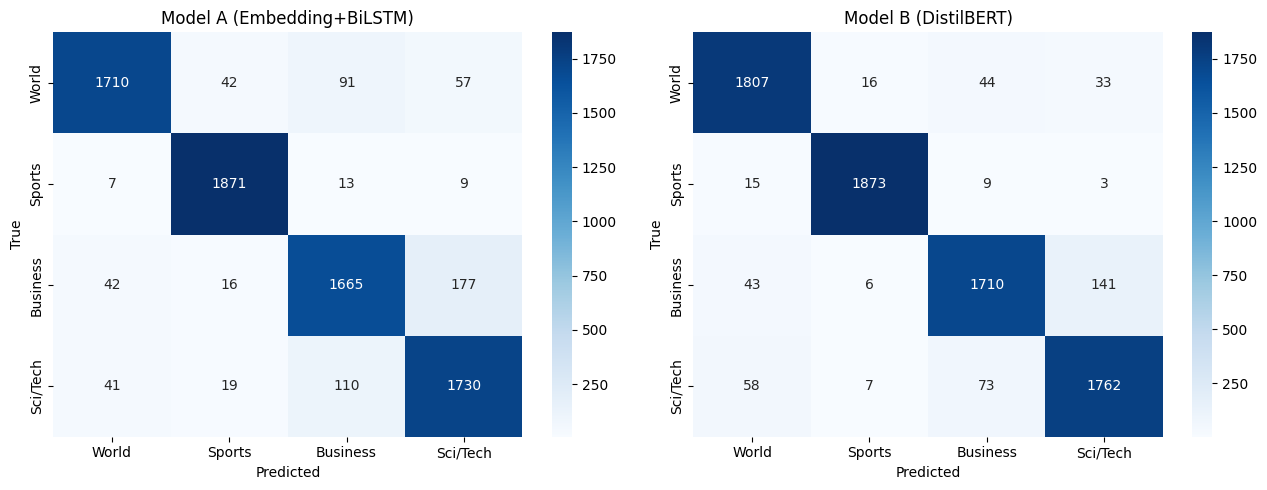

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, pred, name in zip(axes, [pred_a, pred_b], ['Model A (Embedding+BiLSTM)', 'Model B (DistilBERT)']):
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()


### 6.4 Per-class F1 comparison

The code below computes the per-class F1 score for both models and plots them as grouped bar charts, one bar pair per category, so class-level performance can be compared directly rather than relying on a single overall accuracy figure.

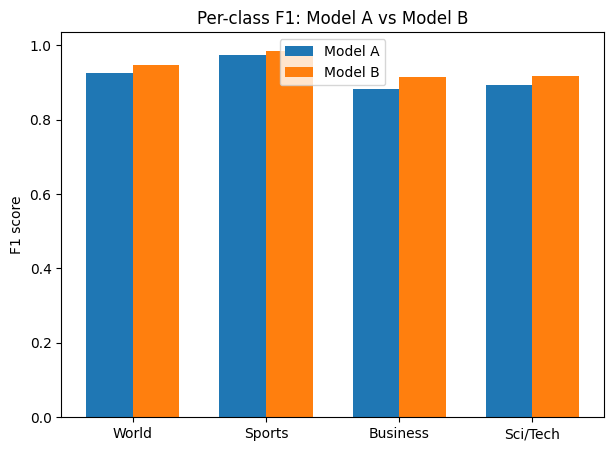

In [24]:
from sklearn.metrics import f1_score

f1_a = f1_score(y_true, pred_a, average=None)
f1_b = f1_score(y_true, pred_b, average=None)

x = np.arange(len(CLASS_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(x - width/2, f1_a, width, label='Model A')
ax.bar(x + width/2, f1_b, width, label='Model B')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1: Model A vs Model B')
ax.legend()
plt.show()


### 6.5 t-SNE projection of learned representations (2D and 3D)
Visualises how well each model separates classes internally, not just via final predictions. The code below extracts intermediate representations, the second-to-last dense layer for Model A and the pooled CLS hidden state for Model B, projects a random sample of them down to two dimensions with t-SNE, and plots the result colored by true class label.

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


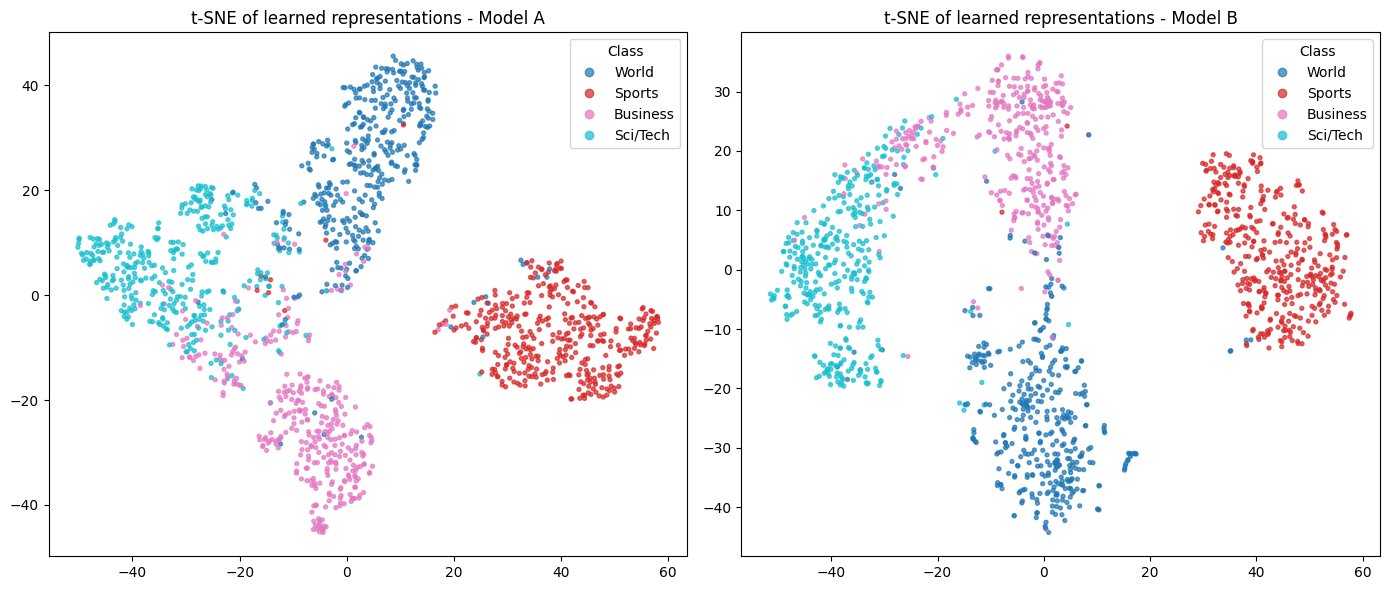

In [25]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test_a), size=1500, replace=False)

feat_extractor_a = Model(inputs=model_a.input, outputs=model_a.layers[-2].output)
repr_a = feat_extractor_a.predict(X_test_a[sample_idx])

def extract_cls_features(encodings, idx, batch_size=64):

    backbone = bert_model.distilbert
    backbone.eval()
    idx_t = torch.as_tensor(idx)
    feats = []
    with torch.no_grad():
        for start_i in range(0, len(idx_t), batch_size):
            chunk = idx_t[start_i:start_i + batch_size]
            batch = {k: v[chunk].to(device) for k, v in encodings.items()}
            hidden = backbone(**batch).last_hidden_state
            feats.append(hidden[:, 0, :].cpu())
    return torch.cat(feats).numpy()

repr_b = extract_cls_features(test_enc, sample_idx)

labels_sample = y_true[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, repr_, name in zip(axes, [repr_a, repr_b], ['Model A', 'Model B']):
    tsne = TSNE(n_components=2, random_state=SEED, init='pca')
    proj = tsne.fit_transform(repr_)
    scatter = ax.scatter(proj[:,0], proj[:,1], c=labels_sample, cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f't-SNE of learned representations - {name}')
    handles = scatter.legend_elements()[0]
    ax.legend(handles, CLASS_NAMES, title='Class')
plt.tight_layout()
plt.show()


In [26]:
import plotly.express as px
from IPython.display import display, HTML

def plot_3d_tsne(repr_, labels, class_names, title):
    tsne3d = TSNE(n_components=3, random_state=SEED, init='pca')
    proj3d = tsne3d.fit_transform(repr_)

    df_plot = pd.DataFrame({
        'x': proj3d[:, 0], 'y': proj3d[:, 1],
        'z': proj3d[:, 2], 'class': [class_names[l] for l in labels]
    })

    fig = px.scatter_3d(
        df_plot, x='x', y='y', z='z', color='class',
        title=title, opacity=0.7,
        width=800, height=650)
    fig.update_traces(marker=dict(size=3))

    display(HTML(fig.to_html(include_plotlyjs=True, full_html=False)))

# Model A
plot_3d_tsne(repr_a, labels_sample, CLASS_NAMES, '3D t-SNE for Model A (Embedding+BiLSTM)')

# Model B
plot_3d_tsne(repr_b, labels_sample, CLASS_NAMES, '3D t-SNE for Model B (DistilBERT)')

Output hidden; open in https://colab.research.google.com to view.

### 6.6 Error overlap analysis
Shows whether both models make the *same* mistakes or *complementary*
mistakes - relevant to whether ensembling would help.
The code below builds a set of misclassified test indices for each model, draws a two-circle Venn diagram of the overlap between them, and prints how many errors are unique to each model versus shared by both.

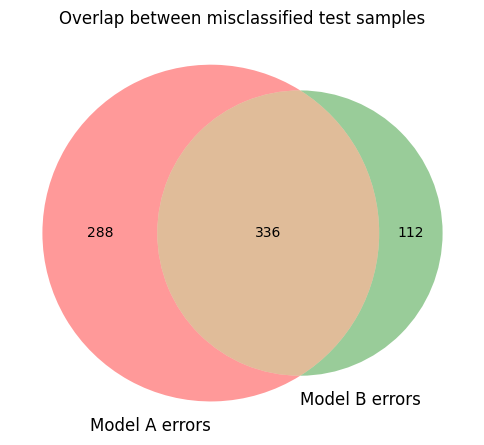

Only Model A wrong: 288
Only Model B wrong: 112
Both wrong: 336


In [27]:
from matplotlib_venn import venn2

errors_a = set(np.where(pred_a != y_true)[0])
errors_b = set(np.where(pred_b != y_true)[0])

plt.figure(figsize=(6,6))
venn2([errors_a, errors_b], set_labels=('Model A errors', 'Model B errors'))
plt.title('Overlap between misclassified test samples')
plt.show()

only_a = errors_a - errors_b
only_b = errors_b - errors_a
both   = errors_a & errors_b
print(f'Only Model A wrong: {len(only_a)}')
print(f'Only Model B wrong: {len(only_b)}')
print(f'Both wrong: {len(both)}')


### 6.7 Qualitative misclassification inspection

The code below randomly samples a few misclassified examples from each error category, errors shared by both models and errors unique to each, then prints their text alongside the true and predicted labels for manual inspection.

In [28]:
def show_examples(error_idx_set, n=5, title=''):
    idxs = random.sample(list(error_idx_set), min(n, len(error_idx_set)))
    print(f'{title}')
    for i in idxs:
        print(f"Text: {test_df.iloc[i]['clean_text'][:150]}...")
        print(f"True: {CLASS_NAMES[y_true[i]]} | Pred A: {CLASS_NAMES[pred_a[i]]} | "
              f"Pred B: {CLASS_NAMES[pred_b[i]]}")
        print()

show_examples(both, n=5, title='Examples that both models got wrong')
show_examples(only_a, n=5, title='Examples only Model A got wrong')
show_examples(only_b, n=5, title='Examples only Model B got wrong')


Examples that both models got wrong
Text: Microsoft open new software development unit in India (AFP) AFP - Microsoft said it will join with India's second-largest software firm, Infosys Techn...
True: World | Pred A: Sci/Tech | Pred B: Sci/Tech

Text: Google #39;s New PC Search Tool Poses Risks NEW YORK Oct. 18, 2004 - People who use public or workplace computers for e-mail, instant messaging and We...
True: Business | Pred A: Sci/Tech | Pred B: Sci/Tech

Text: Icing call Out of money, out of patience, out of time, and for the foreseeable future, out of business....
True: Sports | Pred A: Business | Pred B: Business

Text: R.I.P. Gary Webb -- Unembedded Reporter The finest journalist ever to get fired for telling the truth is dead at age 49. The official cause of death o...
True: Sci/Tech | Pred A: World | Pred B: World

Text: Before-the-Bell: GenCorp Falls 5.6 Pct. (Reuters) Reuters - Shares of GenCorp Inc. fell 5.6percent before the opening bell on Monday after investment ...
True: 

### 6.8 Efficiency / trade-off comparison

The code below compares both models on parameter count, training time, and inference time on a batch of 500 test samples, then plots their test accuracy side by side so the accuracy-versus-cost trade-off is visible at a glance.

In [29]:
params_a = model_a.count_params()
params_b = sum(p.numel() for p in bert_model.parameters())

acc_a = (pred_a == y_true).mean()
acc_b = (pred_b == y_true).mean()

start = time.time()
_ = model_a.predict(X_test_a[:500])
infer_time_a = time.time() - start

small_test_dataset = BertDataset({k: v[:500] for k, v in test_enc.items()}, y_test_b[:500])
small_test_loader = DataLoader(small_test_dataset, batch_size=32)

bert_model.eval()
start = time.time()
with torch.no_grad():
    for batch in small_test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        _ = bert_model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
infer_time_b = time.time() - start

comparison_df = pd.DataFrame({
    'Model': ['Model A (Embedding+BiLSTM)', 'Model B (DistilBERT)'],
    'Test Accuracy': [acc_a, acc_b],
    'Params (millions)': [params_a/1e6, params_b/1e6],
    'Train Time (s)': [train_time_a, train_time_b],
    'Inference Time / 500 samples (s)': [infer_time_a, infer_time_b],
})
comparison_df


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,Model,Test Accuracy,Params (millions),Train Time (s),Inference Time / 500 samples (s)
0,Model A (Embedding+BiLSTM),0.917895,1.280296,113.365154,0.150742
1,Model B (DistilBERT),0.941053,66.956548,930.871217,0.373538


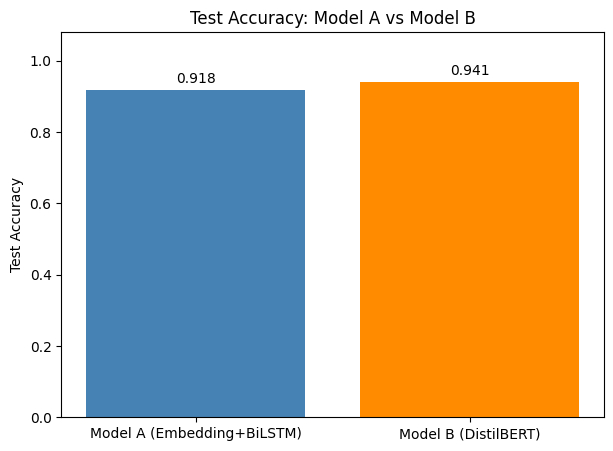

In [30]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.bar(comparison_df['Model'], comparison_df['Test Accuracy'], color=['steelblue','darkorange'])
ax1.set_ylabel('Test Accuracy')
ax1.set_ylim(0, 1.08)
for i, v in enumerate(comparison_df['Test Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.title('Test Accuracy: Model A vs Model B')
plt.show()


## 7. Discussion & Conclusion

Address the following in your report (this is the highest-weighted, most
differentiating part of the rubric - be specific and reference your figures
by number):

- **Performance:** Which model performed better overall and per-class? Does
  this match what your EDA (Section 2.6/2.8) predicted?
- **Strengths/weaknesses:** What does the t-SNE plot (6.5) reveal about how
  cleanly each model separates classes internally?
- **Error behaviour:** What did the error overlap (6.6) and qualitative
  inspection (6.7) reveal: are errors complementary or shared? What kinds of
  articles are hardest to classify, and why?
- **Trade-offs:** Using the efficiency comparison (6.8), discuss accuracy vs.
  model size vs. training/inference time: when would each model be the
  practical choice?
- **Future improvements:** e.g. trainable embeddings, larger transformer,
  ensembling Models A+B, data augmentation, hyperparameter tuning,
  handling the most-confused class pair specifically.

*(Write your final discussion here.)*
